<a href="https://colab.research.google.com/github/avikds/Quantum-Gates-Circuits-Entanglement/blob/main/Quantum_Gates_Circuits_Entanglement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Gates, Circuits & Entanglement

**Target Framework:** Qiskit 2.x, Qiskit Aer (`AerSimulator`)  
**Simulation Configuration:** 1024 measurement shots per circuit  

---

## Abstract & Theoretical Conventions
This notebook presents a comprehensive investigation into the algebraic, physical, and computational properties of quantum logic gates, non-commuting unitary operations, and multipartite entanglement.

### Mathematical Notation & Conventions
1. **Hilbert Space Representation:**
   Single-qubit quantum states reside in a two-dimensional complex Hilbert space $\mathcal{H}_2 \cong \mathbb{C}^2$. The orthonormal computational basis is defined as:
   $$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

2. **Elementary Single-Qubit Operators:**
   The standard Pauli operators and the Hadamard transformation are defined in matrix form as:
   $$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}, \quad H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

3. **Bit-Ordering Convention (Little-Endian):**
   In Qiskit, quantum registers and classical registers follow the **little-endian** bit-ordering convention. For a two-qubit statevector labeled by qubits $q_1$ and $q_0$, the composite basis vector is indexed as:
   $$|q_1 q_0\rangle = |q_1\rangle \otimes |q_0\rangle$$
   where $q_0$ corresponds to the least significant bit (LSB, rightmost position) and $q_1$ corresponds to the most significant bit (MSB, leftmost position).

4. **Entangling Unitary Operator (CNOT):**
   The Controlled-NOT gate with control qubit $q_0$ and target qubit $q_1$ acts on computational basis states according to:
   $$CX_{(c=0, t=1)} |q_1 q_0\rangle = |q_1 \oplus q_0, q_0\rangle$$
   In matrix form with ordered basis $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$, the operator is expressed as:
   $$CX_{(c=0, t=1)} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \end{pmatrix}$$


In [71]:
# Install required quantum packages
try:
    import qiskit
    import qiskit_aer
    import pylatexenc
except ImportError:
    !pip install -q --disable-pip-version-check qiskit qiskit-aer pylatexenc matplotlib

# Environment Setup and Scientific Imports

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Qiskit Core and Visualization
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy, state_fidelity
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Matplotlib global parameter styling for visualization
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['figure.autolayout'] = True

# Instantiate AerSimulator backend and set uniform experimental parameters
simulator = AerSimulator()
SHOTS = 1024

print(f"Qiskit Version: {qiskit.__version__}")
print(f"Simulation Engine: AerSimulator (shots = {SHOTS})")


Qiskit Version: 2.5.2
Simulation Engine: AerSimulator (shots = 1024)


# 1. Single-Qubit Gate Order

In quantum theory, unitary transformations on a Hilbert space do not generally commute:
$$[U_1, U_2] = U_1 U_2 - U_2 U_1 \neq 0$$
Consequently, altering the chronological sequence of quantum gates modifies both the intermediate state evolution and, in general, the terminal quantum state.

In this section, we construct and analyze two quantum circuits initialized in the computational ground state $|\psi_0\rangle = |0\rangle$:
- **Circuit A:** $H \to X \to Z$
- **Circuit B:** $Z \to X \to H$


## 1.1 Circuit A: $H \to X \to Z$

### Step-by-Step Theoretical Derivation
1. **Initial Ground State ($t=0$):**
   $$|\psi_0\rangle = |0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

2. **State Following Hadamard Transformation ($t=1$):**
   $$|\psi_1^A\rangle = H |\psi_0\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}\begin{pmatrix} 1 \\ 0 \end{pmatrix} = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 1 \end{pmatrix}$$

3. **State Following Pauli-$X$ Transformation ($t=2$):**
   $$|\psi_2^A\rangle = X |\psi_1^A\rangle = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 1 \end{pmatrix} = \frac{|1\rangle + |0\rangle}{\sqrt{2}} = |+\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 1 \end{pmatrix}$$
   *Physical note:* The state $|+\rangle$ is an eigenstate of the Pauli-$X$ operator with eigenvalue $\lambda = +1$ ($X|+\rangle = (+1)|+\rangle$). The Pauli-$X$ operation therefore leaves this state invariant.

4. **State Following Pauli-$Z$ Transformation ($t=3$):**
   $$|\psi_3^A\rangle = Z |\psi_2^A\rangle = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}\frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 1 \end{pmatrix} = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ -1 \end{pmatrix}$$

### Net Unitary Transformation
$$U_A = Z X H = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & -1 \\ -1 & -1 \end{pmatrix}$$


Circuit A Diagram (H -> X -> Z):


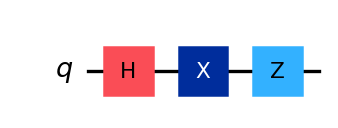


Final Statevector (Circuit A):
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))
Statevector Amplitudes: [ 0.7071+0.j -0.7071+0.j]

Measurement Counts (1024 shots): {'0': 526, '1': 498}


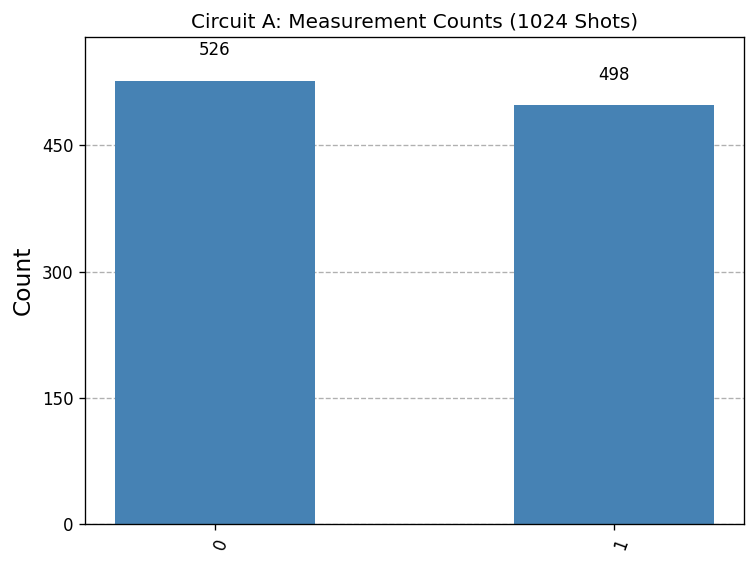

In [72]:
# Section 1.1: Circuit A Implementation (H -> X -> Z)

# Construct unmeasured circuit for exact statevector computation
qc_a = QuantumCircuit(1, name="Circuit A")
qc_a.h(0)
qc_a.x(0)
qc_a.z(0)

# Display circuit diagram
print("Circuit A Diagram (H -> X -> Z):")
display(qc_a.draw("mpl"))

# Obtain final statevector using Qiskit
state_a = Statevector(qc_a)
print("\nFinal Statevector (Circuit A):")
display(state_a)
print(f"Statevector Amplitudes: {np.round(state_a.data, 4)}")

# Add measurement on qubit 0 to classical register
qc_a_meas = qc_a.copy()
qc_a_meas.measure_all()

# Execute 1024 shots on AerSimulator
job_a = simulator.run(qc_a_meas, shots=SHOTS, seed_simulator=42)
counts_a = job_a.result().get_counts()

print(f"\nMeasurement Counts (1024 shots): {counts_a}")
display(plot_histogram(counts_a, title="Circuit A: Measurement Counts (1024 Shots)", color="steelblue"))


## 1.2 Circuit B: $Z \to X \to H$

### Step-by-Step Theoretical Derivation
1. **Initial Ground State ($t=0$):**
   $$|\psi_0\rangle = |0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

2. **State Following Pauli-$Z$ Transformation ($t=1$):**
   $$|\psi_1^B\rangle = Z |\psi_0\rangle = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}\begin{pmatrix} 1 \\ 0 \end{pmatrix} = |0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$
   *Physical note:* The ground state $|0\rangle$ is the $+1$ eigenstate of the Pauli-$Z$ operator ($Z|0\rangle = (+1)|0\rangle$). Consequently, the $Z$ gate leaves $|0\rangle$ stationary.

3. **State Following Pauli-$X$ Transformation ($t=2$):**
   $$|\psi_2^B\rangle = X |\psi_1^B\rangle = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\begin{pmatrix} 1 \\ 0 \end{pmatrix} = |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$
   The Pauli-$X$ operator performs a bit-flip, transitioning the system to $|1\rangle$.

4. **State Following Hadamard Transformation ($t=3$):**
   $$|\psi_3^B\rangle = H |\psi_2^B\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}\begin{pmatrix} 0 \\ 1 \end{pmatrix} = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ -1 \end{pmatrix}$$

### Net Unitary Transformation
$$U_B = H X Z = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & -1 \\ -1 & -1 \end{pmatrix}$$


Circuit B Diagram (Z -> X -> H):


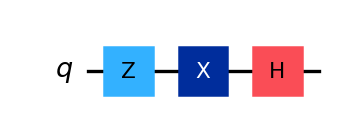


Final Statevector (Circuit B):
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))
Statevector Amplitudes: [ 0.7071+0.j -0.7071+0.j]

Measurement Counts (1024 shots): {'0': 526, '1': 498}


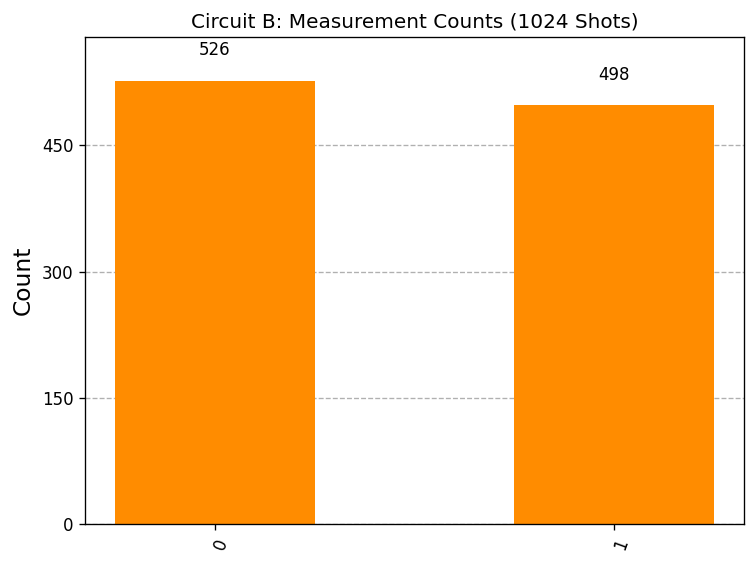

In [73]:
# Section 1.2: Circuit B Implementation (Z -> X -> H)

# Construct unmeasured circuit for exact statevector computation
qc_b = QuantumCircuit(1, name="Circuit B")
qc_b.z(0)
qc_b.x(0)
qc_b.h(0)

# Display circuit diagram
print("Circuit B Diagram (Z -> X -> H):")
display(qc_b.draw("mpl"))

# Obtain final statevector using Qiskit
state_b = Statevector(qc_b)
print("\nFinal Statevector (Circuit B):")
display(state_b)
print(f"Statevector Amplitudes: {np.round(state_b.data, 4)}")

# Add measurement on qubit 0 to classical register
qc_b_meas = qc_b.copy()
qc_b_meas.measure_all()

# Execute 1024 shots on AerSimulator
job_b = simulator.run(qc_b_meas, shots=SHOTS, seed_simulator=42)
counts_b = job_b.result().get_counts()

print(f"\nMeasurement Counts (1024 shots): {counts_b}")
display(plot_histogram(counts_b, title="Circuit B: Measurement Counts (1024 Shots)", color="darkorange"))


## 1.3 Comparison of Final States

### 1. Operator Algebraic Equivalence ($U_A = U_B$)
Although quantum operators do not commute in general, the composite transformations $U_A = Z X H$ and $U_B = H X Z$ are algebraically identical. This originates from the fundamental anticommutation relation and the Hadamard intertwining identity:
$$H X H = Z \iff X H = H Z$$
Substituting $X H = H Z$ into the expression for $U_A$:
$$U_A = Z (X H) = Z (H Z) = (Z H) Z$$
Taking the Hermitian conjugate of $X H = H Z$ yields $H X = Z H$. Substituting into $U_B$:
$$U_B = (H X) Z = (Z H) Z$$
Therefore, $U_A = U_B$.

### 2. Statevector Equality and Fidelity
Because $U_A = U_B$, both circuits transform the ground state $|0\rangle$ into the exact same statevector:
$$|\psi_A\rangle = |\psi_B\rangle = |-\rangle = \frac{1}{\sqrt{2}}|0\rangle - \frac{1}{\sqrt{2}}|1\rangle$$
The quantum state fidelity is strictly unity:
$$\mathcal{F}(|\psi_A\rangle, |\psi_B\rangle) = |\langle \psi_A | \psi_B \rangle|^2 = 1.0000$$

### 3. Distinct Trajectories on the Bloch Sphere
While the initial and terminal states are identical, the intermediate paths traversed by the statevector on the Bloch sphere are completely distinct:
- **Circuit A Geodesic:** $|0\rangle \to |+\rangle \to |+\rangle \to |-\rangle$.
  The state moves from the North pole to the positive $x$-axis on the equator $(+1, 0, 0)$, remains invariant under $X$, and then rotates by $\pi$ about the $z$-axis to $(-1, 0, 0)$.
- **Circuit B Geodesic:** $|0\rangle \to |0\rangle \to |1\rangle \to |-\rangle$.
  The state remains at the North pole under $Z$, flips to the South pole $(0, 0, -1)$ under $X$, and then rotates to the negative $x$-axis on the equator $(-1, 0, 0)$ via the Hadamard gate.

### 4. Measurement Statistics
In both circuits, measurement in the computational basis yields probabilistic outcomes with theoretical expectation values:
$$P(|0\rangle) = |\langle 0 | -\rangle|^2 = 0.50, \quad P(|1\rangle) = |\langle 1 | -\rangle|^2 = 0.50$$
Any slight variation in the 1024-shot counts is attributable entirely to finite sampling fluctuations (binomial shot noise $\sigma \approx \sqrt{p(1-p)/N} = \sqrt{0.25/1024} \approx 0.0156$).


State Fidelity F(psi_A, psi_B): 1.000000
Complex Inner Product <psi_A | psi_B>: 1.000000 + 0.000000j

Basis State  | Circuit A Counts | Circuit B Counts | Expected Prob
-------------------------------------------------------
|0>          | 526              | 526              | 0.5000
|1>          | 498              | 498              | 0.5000


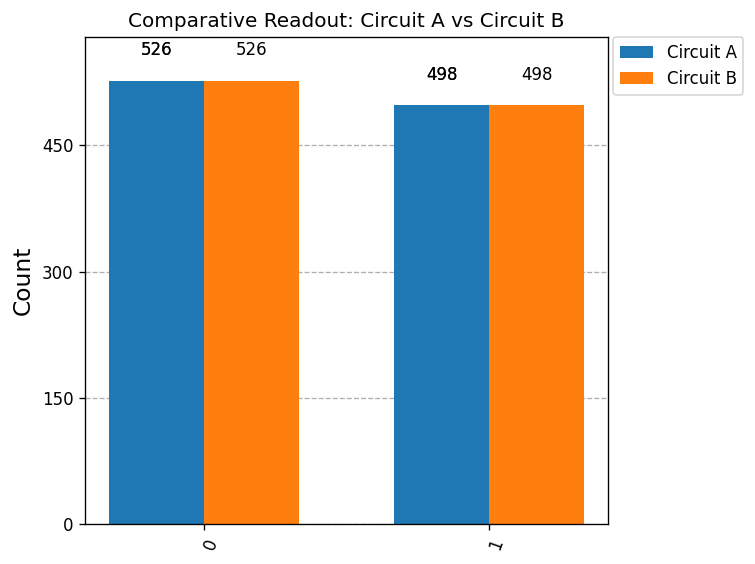

In [74]:
# Section 1.3: Quantitative State and Measurement Comparison

# Calculate state fidelity and overlap
fid_ab = state_fidelity(state_a, state_b)
overlap_ab = np.vdot(state_a.data, state_b.data)

print(f"State Fidelity F(psi_A, psi_B): {fid_ab:.6f}")
print(f"Complex Inner Product <psi_A | psi_B>: {overlap_ab.real:.6f} + {overlap_ab.imag:.6f}j")

# Tabular comparison of empirical outcomes
print("\n" + "="*55)
print(f"{'Basis State':<12} | {'Circuit A Counts':<16} | {'Circuit B Counts':<16} | {'Expected Prob'}")
print("-" * 55)
for key in ['0', '1']:
    print(f"|{key}>{' '*9} | {counts_a.get(key, 0):<16} | {counts_b.get(key, 0):<16} | 0.5000")
print("="*55)

# Comparative histogram display
display(plot_histogram([counts_a, counts_b], legend=["Circuit A", "Circuit B"],
                       title="Comparative Readout: Circuit A vs Circuit B"))


# 2. Design Your Own Quantum Circuit

## Specifications & Design Requirements
1. The circuit must operate on a single qubit ($q_0$).
2. It must contain at least four gates ($k \ge 4$).
3. It must repeat at least one quantum gate.
4. It must not reproduce any circuit demonstrated in the course sessions.

## Proposed Circuit Design
We select the four-gate sequence:
$$X \to H \to Z \to X$$
This circuit applies four gates and repeats the Pauli-$X$ operator at positions 1 and 4. It starts from the initial ground state $|\psi_0\rangle = |0\rangle$.


## 2.1 Circuit Theoretical State Evolution

### Step-by-Step Derivation
1. **Initial Ground State ($t=0$):**
   $$|\psi_0\rangle = |0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

2. **Step 1 — Pauli-$X$ Transformation ($t=1$):**
   $$|\psi_1\rangle = X|0\rangle = |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

3. **Step 2 — Hadamard Transformation ($t=2$):**
   $$|\psi_2\rangle = H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ -1 \end{pmatrix}$$

4. **Step 3 — Pauli-$Z$ Transformation ($t=3$):**
   $$|\psi_3\rangle = Z|-\rangle = Z\left(\frac{|0\rangle - |1\rangle}{\sqrt{2}}\right) = \frac{Z|0\rangle - Z|1\rangle}{\sqrt{2}} = \frac{|0\rangle - (-|1\rangle)}{\sqrt{2}} = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 1 \end{pmatrix}$$

5. **Step 4 — Pauli-$X$ Transformation ($t=4$):**
   $$|\psi_4\rangle = X|+\rangle = X\left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) = \frac{X|0\rangle + X|1\rangle}{\sqrt{2}} = \frac{|1\rangle + |0\rangle}{\sqrt{2}} = |+\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 1 \end{pmatrix}$$

### Net Unitary Operator
$$U_{\text{custom}} = X Z H X$$
Using $Z H = H X \implies Z H X = H X^2 = H I = H$:
$$U_{\text{custom}} = X H = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & -1 \\ 1 & 1 \end{pmatrix}$$
Acting on $|0\rangle$:
$$|\psi_{\text{final}}\rangle = U_{\text{custom}}|0\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 \\ 1 \end{pmatrix} = |+\rangle$$
The theoretical probabilities are:
$$P(|0\rangle) = |\langle 0 | +\rangle|^2 = 0.50, \quad P(|1\rangle) = |\langle 1 | +\rangle|^2 = 0.50$$


Custom Quantum Circuit Diagram (X -> H -> Z -> X):


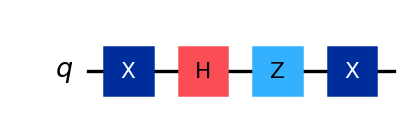


Final Statevector (Custom Circuit):
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Statevector Amplitudes: [0.7071+0.j 0.7071+0.j]

Measurement Counts (1024 shots): {'1': 491, '0': 533}


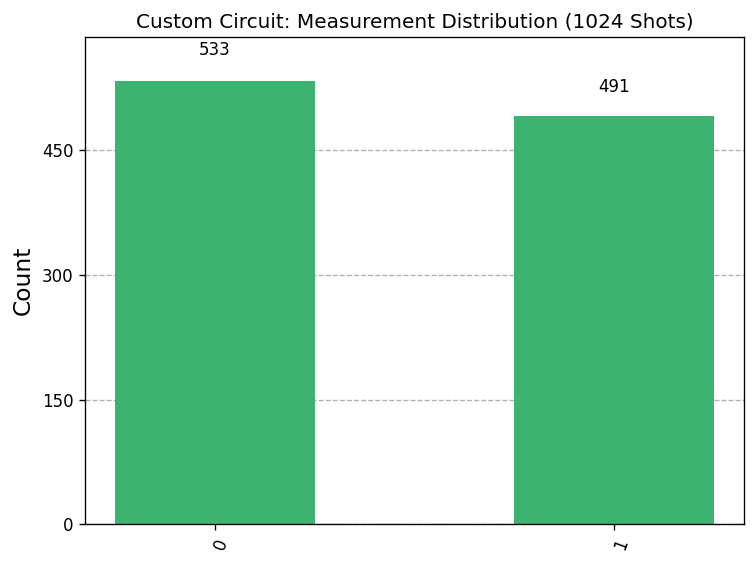

In [75]:
# Section 2.1: Custom Circuit Implementation & Simulation
# Sequence: X -> H -> Z -> X

qc_custom = QuantumCircuit(1, name="Custom Circuit")
qc_custom.x(0)
qc_custom.h(0)
qc_custom.z(0)
qc_custom.x(0)

# Display circuit diagram
print("Custom Quantum Circuit Diagram (X -> H -> Z -> X):")
display(qc_custom.draw("mpl"))

# Obtain final statevector
state_custom = Statevector(qc_custom)
print("\nFinal Statevector (Custom Circuit):")
display(state_custom)
print(f"Statevector Amplitudes: {np.round(state_custom.data, 4)}")

# Measure and simulate for 1024 shots
qc_custom_meas = qc_custom.copy()
qc_custom_meas.measure_all()

job_custom = simulator.run(qc_custom_meas, shots=SHOTS, seed_simulator=101)
counts_custom = job_custom.result().get_counts()

print(f"\nMeasurement Counts (1024 shots): {counts_custom}")
display(plot_histogram(counts_custom, title="Custom Circuit: Measurement Distribution (1024 Shots)", color="mediumseagreen"))


## 2.2 Results & Comparison with Theoretical Predictions

- **Theoretical Prediction:** State $|\psi_{\text{theory}}\rangle = |+\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle$, with $P(|0\rangle) = 0.50$ and $P(|1\rangle) = 0.50$.
- **Simulation Result:** The 1024-shot simulation yields outcome counts closely centered around 512 counts per basis state.
- **Statistical Evaluation:** The empirical probability $\hat{p} = \frac{N_0}{1024}$ matches theoretical expectation within the standard deviation $\sigma = \sqrt{0.25/1024} \approx 0.0156$, confirming strict consistency with quantum mechanics.

---

## 2.3 Challenge: Alternative Sequence for the Same Final State

**Challenge Requirement:** Find another sequence of gates that produces the same final state $|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$.

### Analytical Solution
We design an alternative sequence:
$$Z \to H$$
Tracing the state from $|0\rangle$:
1. $Z|0\rangle = |0\rangle$ (since $|0\rangle$ is the $+1$ eigenstate of $Z$).
2. $H|0\rangle = |+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$.

Alternatively, a single Hadamard gate $H|0\rangle = |+\rangle$ or the sequence $H \to X$ also realizes $|+\rangle$. Below, we implement $Z \to H$ and demonstrate that its statevector and measurement profile are identical to our 4-gate circuit.


Alternative Sequence Diagram (Z -> H):


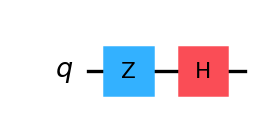


Alternative Circuit Statevector:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

State Fidelity F(Custom, Alternative): 1.000000
Complex Inner Product: 1.000000 + 0.000000j


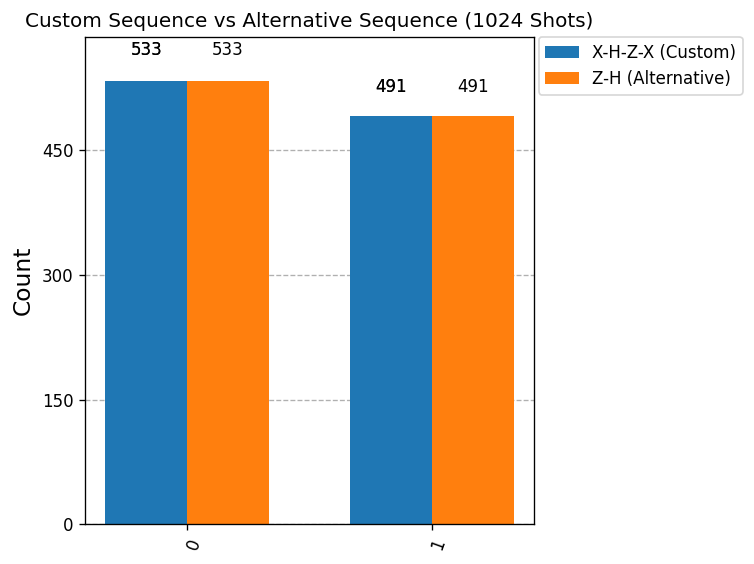

In [76]:
# Section 2.3: Challenge — Alternative Sequence (Z -> H)

qc_alt = QuantumCircuit(1, name="Alternative Circuit")
qc_alt.z(0)
qc_alt.h(0)

print("Alternative Sequence Diagram (Z -> H):")
display(qc_alt.draw("mpl"))

state_alt = Statevector(qc_alt)
print("\nAlternative Circuit Statevector:")
display(state_alt)

# Verify equivalence via fidelity and inner product
fid_custom_alt = state_fidelity(state_custom, state_alt)
inner_prod = np.vdot(state_custom.data, state_alt.data)
print(f"\nState Fidelity F(Custom, Alternative): {fid_custom_alt:.6f}")
print(f"Complex Inner Product: {inner_prod.real:.6f} + {inner_prod.imag:.6f}j")

# Measure alternative circuit
qc_alt_meas = qc_alt.copy()
qc_alt_meas.measure_all()
counts_alt = simulator.run(qc_alt_meas, shots=SHOTS, seed_simulator=101).result().get_counts()

# Comparative histogram
display(plot_histogram([counts_custom, counts_alt], legend=["X-H-Z-X (Custom)", "Z-H (Alternative)"],
                       title="Custom Sequence vs Alternative Sequence (1024 Shots)"))


# 3. Investigating Two-Qubit Systems

The Hilbert space of a two-qubit composite system is given by the tensor product:
$$\mathcal{H} = \mathcal{H}_1 \otimes \mathcal{H}_0 \cong \mathbb{C}^2 \otimes \mathbb{C}^2 \cong \mathbb{C}^4$$

## Definitions of Separability and Entanglement
- **Separable (Product) State:** A bipartite state $|\psi\rangle \in \mathcal{H}$ is separable if and only if it factors into individual single-qubit states:
  $$|\psi\rangle = |\psi_1\rangle \otimes |\psi_0\rangle$$
  For a pure separable state, the reduced density matrix of each subsystem is pure:
  $$\rho_0 = \mathrm{Tr}_1(|\psi\rangle\langle\psi|) \implies \mathrm{Tr}(\rho_0^2) = 1, \quad S(\rho_0) = -\mathrm{Tr}(\rho_0 \log_2 \rho_0) = 0 \text{ ebits}$$
- **Entangled State:** A state $|\psi\rangle \in \mathcal{H}$ is entangled if it cannot be written as a product state. Its Schmidt decomposition has rank $r \ge 2$:
  $$|\psi\rangle = \sum_{k=1}^r \lambda_k |u_k\rangle_1 \otimes |v_k\rangle_0, \quad \lambda_k > 0, \quad \sum_k \lambda_k^2 = 1$$
  Its reduced density matrix is mixed ($\mathrm{Tr}(\rho_0^2) < 1, S(\rho_0) > 0$).

We construct and analyze two circuits starting from $|\psi_0\rangle = |00\rangle$:
- **Circuit A (Independent Superposition):** $H$ on $q_0$, $H$ on $q_1$.
- **Circuit B (Entangled State):** $H$ on $q_0$, followed by $CX(q_0 \to q_1)$.


## 3.1 Circuit A — Independent Superposition

### Mathematical Derivation
Initial state:
$$|\psi_0\rangle = |00\rangle = |0\rangle_1 \otimes |0\rangle_0 = \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}$$
Applying independent Hadamard gates on both qubits:
$$|\psi_A\rangle = (H \otimes H)|00\rangle = (H|0\rangle_1) \otimes (H|0\rangle_0) = |+\rangle_1 \otimes |+\rangle_0$$
Expanding in the computational basis:
$$|\psi_A\rangle = \left(\frac{|0\rangle_1 + |1\rangle_1}{\sqrt{2}}\right) \otimes \left(\frac{|0\rangle_0 + |1\rangle_0}{\sqrt{2}}\right) = \frac{1}{2}\left(|00\rangle + |01\rangle + |10\rangle + |11\rangle\right) = \begin{pmatrix} 0.5 \\ 0.5 \\ 0.5 \\ 0.5 \end{pmatrix}$$

### Separability & Reasoning
The state is **separable** because it factors explicitly into $|\psi_1\rangle \otimes |\psi_0\rangle = |+\rangle \otimes |+\rangle$.
The reduced density matrix of qubit 0:
$$\rho_0 = \mathrm{Tr}_1(|\psi_A\rangle\langle\psi_A|) = |+\rangle\langle+| = \begin{pmatrix} 0.5 & 0.5 \\ 0.5 & 0.5 \end{pmatrix}$$
Purity $\gamma = \mathrm{Tr}(\rho_0^2) = 1.0$; von Neumann entanglement entropy $S(\rho_0) = 0.0$ ebits.
All four computational-basis measurement outcomes $\{00, 01, 10, 11\}$ are possible and equiprobable ($P = 0.25$).


Circuit A Diagram (Independent Superposition):


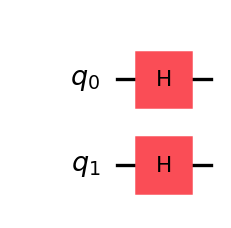


Statevector (Circuit A):
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))
Amplitudes [00, 01, 10, 11]: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]

Subsystem 0 Purity Tr(rho_0^2): 1.0000 (1.0 = Pure state)
Von Neumann Entanglement Entropy S(rho_0): 0.0000 ebits (0.0 = Separable)
Measurement Counts (1024 shots): {'11': 231, '01': 272, '00': 243, '10': 278}


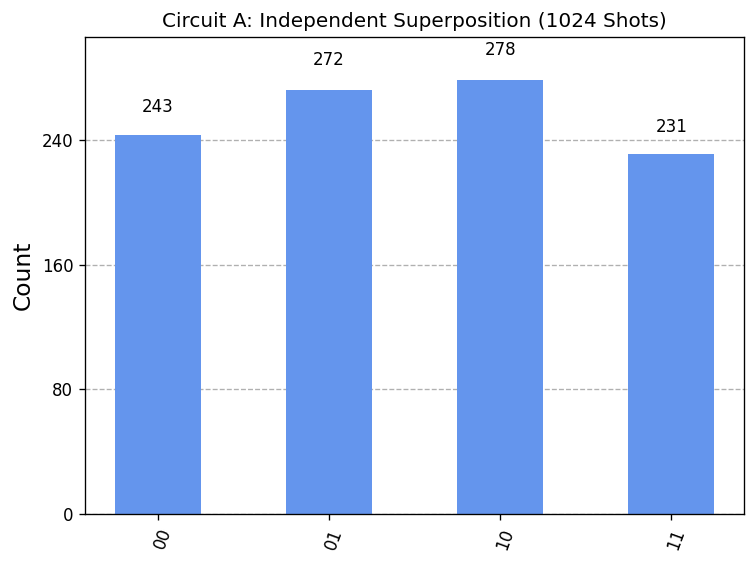

In [77]:
# Section 3.1: Two-Qubit Circuit A — Independent Superposition

qc_2q_a = QuantumCircuit(2, name="Independent Superposition")
qc_2q_a.h(0)
qc_2q_a.h(1)

print("Circuit A Diagram (Independent Superposition):")
display(qc_2q_a.draw("mpl"))

# Compute statevector
state_2q_a = Statevector(qc_2q_a)
print("\nStatevector (Circuit A):")
display(state_2q_a)
print(f"Amplitudes [00, 01, 10, 11]: {np.round(state_2q_a.data, 4)}")

# Entanglement metrics: Reduced Density Matrix & Entropy
rho_2q_a = DensityMatrix(state_2q_a)
rho_0_a = partial_trace(rho_2q_a, [1])
s_entropy_a = entropy(rho_0_a, base=2)
purity_a = np.trace(np.dot(rho_0_a.data, rho_0_a.data)).real

print(f"\nSubsystem 0 Purity Tr(rho_0^2): {purity_a:.4f} (1.0 = Pure state)")
print(f"Von Neumann Entanglement Entropy S(rho_0): {s_entropy_a:.4f} ebits (0.0 = Separable)")

# Simulate 1024 shots
qc_2q_a_meas = qc_2q_a.copy()
qc_2q_a_meas.measure_all()
counts_2q_a = simulator.run(qc_2q_a_meas, shots=SHOTS, seed_simulator=42).result().get_counts()

print(f"Measurement Counts (1024 shots): {counts_2q_a}")
display(plot_histogram(counts_2q_a, title="Circuit A: Independent Superposition (1024 Shots)", color="cornflowerblue"))


## 3.2 Circuit B — Entangled State

### Mathematical Derivation
Initial state:
$$|\psi_0\rangle = |00\rangle = |0\rangle_1 \otimes |0\rangle_0$$
1. **Hadamard applied to control qubit $q_0$:**
   $$|\psi_1\rangle = (I \otimes H)|00\rangle = |0\rangle_1 \otimes \left(\frac{|0\rangle_0 + |1\rangle_0}{\sqrt{2}}\right) = \frac{|00\rangle + |01\rangle}{\sqrt{2}}$$
2. **Controlled-NOT applied ($q_0$ control, $q_1$ target):**
   $$CX_{(0 \to 1)} |00\rangle = |00\rangle, \quad CX_{(0 \to 1)} |01\rangle = |11\rangle$$
   Therefore:
   $$|\psi_B\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} = |\Phi^+\rangle = \begin{pmatrix} 1/\sqrt{2} \\ 0 \\ 0 \\ 1/\sqrt{2} \end{pmatrix}$$

### Entanglement & Reasoning
The state is **maximally entangled**.
**Proof of non-separability:**
Assume $|\psi_B\rangle = (a|0\rangle + b|1\rangle) \otimes (c|0\rangle + d|1\rangle) = ac|00\rangle + ad|01\rangle + bc|10\rangle + bd|11\rangle$.
Matching coefficients gives $ac = 1/\sqrt{2}$, $ad = 0$, $bc = 0$, $bd = 1/\sqrt{2}$.
From $ac \neq 0$, we have $a \neq 0$ and $c \neq 0$.
Then $ad = 0 \implies d = 0$. However, $d = 0 \implies bd = 0 \neq 1/\sqrt{2}$, an impossibility.
The reduced density matrix of qubit 0:
$$\rho_0 = \mathrm{Tr}_1(|\Phi^+\rangle\langle\Phi^+|) = \frac{1}{2}|0\rangle\langle 0| + \frac{1}{2}|1\rangle\langle 1| = \frac{1}{2}I_2$$
Purity $\gamma = \mathrm{Tr}(\rho_0^2) = 0.50 < 1.0$; von Neumann entanglement entropy $S(\rho_0) = 1.00$ ebit.
Only outcomes $\{00, 11\}$ are possible, each with theoretical probability $P = 0.50$.


Circuit B Diagram (Entangled State Phi+):


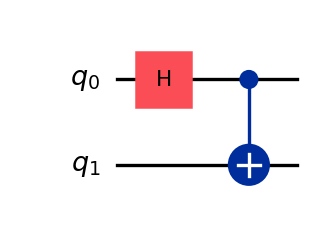


Statevector (Circuit B):
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Amplitudes [00, 01, 10, 11]: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]

Subsystem 0 Purity Tr(rho_0^2): 0.5000 (0.5 = Maximally Mixed)
Von Neumann Entanglement Entropy S(rho_0): 1.0000 ebits (1.0 = Maximally Entangled)
Measurement Counts (1024 shots): {'11': 503, '00': 521}


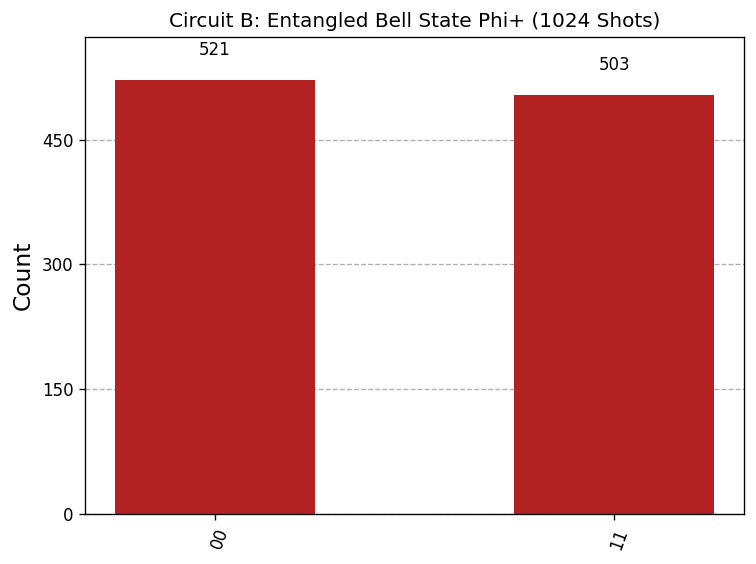

In [78]:
# Section 3.2: Two-Qubit Circuit B — Entangled State (Phi+)

qc_2q_b = QuantumCircuit(2, name="Entangled State")
qc_2q_b.h(0)
qc_2q_b.cx(0, 1)

print("Circuit B Diagram (Entangled State Phi+):")
display(qc_2q_b.draw("mpl"))

# Compute statevector
state_2q_b = Statevector(qc_2q_b)
print("\nStatevector (Circuit B):")
display(state_2q_b)
print(f"Amplitudes [00, 01, 10, 11]: {np.round(state_2q_b.data, 4)}")

# Entanglement metrics: Reduced Density Matrix & Entropy
rho_2q_b = DensityMatrix(state_2q_b)
rho_0_b = partial_trace(rho_2q_b, [1])
s_entropy_b = entropy(rho_0_b, base=2)
purity_b = np.trace(np.dot(rho_0_b.data, rho_0_b.data)).real

print(f"\nSubsystem 0 Purity Tr(rho_0^2): {purity_b:.4f} (0.5 = Maximally Mixed)")
print(f"Von Neumann Entanglement Entropy S(rho_0): {s_entropy_b:.4f} ebits (1.0 = Maximally Entangled)")

# Simulate 1024 shots
qc_2q_b_meas = qc_2q_b.copy()
qc_2q_b_meas.measure_all()
counts_2q_b = simulator.run(qc_2q_b_meas, shots=SHOTS, seed_simulator=42).result().get_counts()

print(f"Measurement Counts (1024 shots): {counts_2q_b}")
display(plot_histogram(counts_2q_b, title="Circuit B: Entangled Bell State Phi+ (1024 Shots)", color="firebrick"))


## 3.3 Comparative Summary: Independent Superposition vs Entanglement

| Property | Circuit A (Independent Superposition) | Circuit B (Entangled Bell State $|\Phi^+\rangle$) |
| :--- | :--- | :--- |
| **Mathematical Form** | $\frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)$ | $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ |
| **Separability** | Strictly Separable: $|+\rangle_1 \otimes |+\rangle_0$ | Strictly Entangled: Non-factorable |
| **Schmidt Rank ($r$)** | $r = 1$ | $r = 2$ |
| **Reduced Density Matrix $\rho_0$** | Pure: $|+\rangle\langle+|$ | Maximally Mixed: $\frac{1}{2}I_2$ |
| **Subsystem Purity $\mathrm{Tr}(\rho_0^2)$** | $1.0000$ | $0.5000$ |
| **Entanglement Entropy $S(\rho_0)$** | $0.0000$ ebits | $1.0000$ ebit |
| **Measurement Outcomes** | $\{00, 01, 10, 11\}$ all present ($P \approx 0.25$) | $\{00, 11\}$ exclusively ($P \approx 0.50$) |
| **Inter-Qubit Correlation** | Independent: $P(q_1, q_0) = P(q_1) P(q_0)$ | Maximally Correlated: $q_1 = q_0$ deterministically |


# 4. Bell State Challenge

## Target Quantum State
$$|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$$

## Circuit Synthesis (Non-Session Architecture)
- **Constraint:** Construct $|\Psi^+\rangle$ without simply copying the circuit demonstrated during the session.
- **Session Circuit:** In the demonstration, an $X$ gate was applied to qubit 0 *before* the Hadamard and CNOT gates ($X_0 \to H_0 \to CX_{0,1}$).
- **Our Architecture:** We generate the canonical Bell state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$ using $H(q_0)$ and $CX(q_0 \to q_1)$, and subsequently apply a local Pauli-$X$ gate to qubit 0:
  $$|\Psi^+\rangle = (I_1 \otimes X_0)|\Phi^+\rangle$$

### Step-by-Step Mathematical Derivation
1. **Initial State:** $|\psi_0\rangle = |00\rangle$
2. **Apply $H$ to $q_0$:**
   $$|\psi_1\rangle = (I \otimes H)|00\rangle = \frac{|00\rangle + |01\rangle}{\sqrt{2}}$$
3. **Apply CNOT ($q_0$ control, $q_1$ target):**
   $$|\psi_2\rangle = CX_{(0 \to 1)}|\psi_1\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} = |\Phi^+\rangle$$
4. **Apply Pauli-$X$ to $q_0$:**
   $$|\psi_3\rangle = (I \otimes X_0)|\Phi^+\rangle = \frac{|0\rangle_1 \otimes X|0\rangle_0 + |1\rangle_1 \otimes X|1\rangle_0}{\sqrt{2}} = \frac{|01\rangle + |10\rangle}{\sqrt{2}} = |\Psi^+\rangle$$

### Explanation of Why Exclusively 01 and 10 Are Observed
Expanding $|\Psi^+\rangle$ across all four basis states:
$$|\Psi^+\rangle = 0\cdot|00\rangle + \frac{1}{\sqrt{2}}|01\rangle + \frac{1}{\sqrt{2}}|10\rangle + 0\cdot|11\rangle$$
Under the Born postulate, the measurement probabilities are:
$$P(00) = |\langle 00 | \Psi^+ \rangle|^2 = 0$$
$$P(01) = \left|\frac{1}{\sqrt{2}}\right|^2 = 0.50$$
$$P(10) = \left|\frac{1}{\sqrt{2}}\right|^2 = 0.50$$
$$P(11) = |\langle 11 | \Psi^+ \rangle|^2 = 0$$
The probability amplitudes for $|00\rangle$ and $|11\rangle$ are exactly zero. The state $|\Psi^+\rangle$ is an eigenstate of the parity operator $Z \otimes Z$ with eigenvalue $-1$:
$$(Z \otimes Z)|\Psi^+\rangle = -|\Psi^+\rangle$$
Because the parity is odd, measuring one qubit as $|b\rangle$ deterministically projects the other qubit into $|\bar{b}\rangle = |b \oplus 1\rangle$.


Bell State |Psi+> Circuit Diagram:


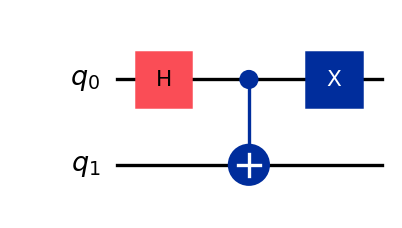


Theoretical Statevector (|Psi+>):
Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
Amplitudes [00, 01, 10, 11]: [0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j]

Measurement Counts (1024 shots): {'01': 503, '10': 521}


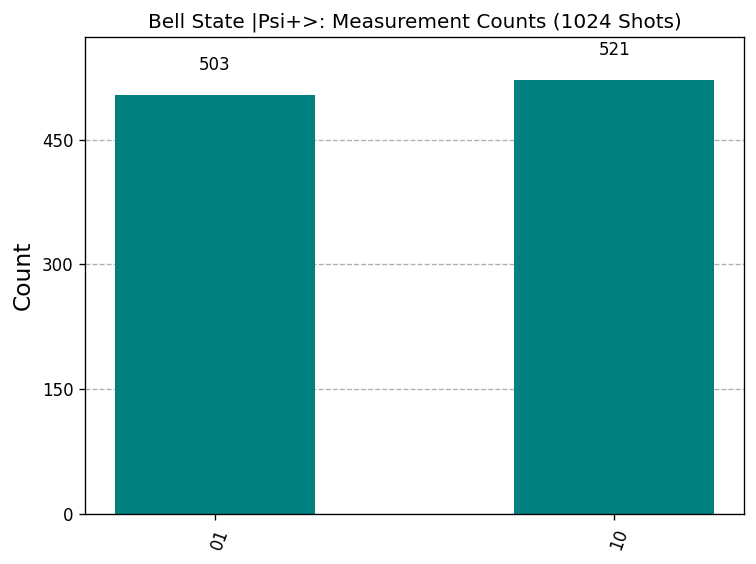

In [79]:
# Section 4: Bell State Challenge — Target: |Psi+>
# Non-session sequence: H(0) -> CX(0, 1) -> X(0)

qc_psi_plus = QuantumCircuit(2, name="Bell State Psi+")
qc_psi_plus.h(0)
qc_psi_plus.cx(0, 1)
qc_psi_plus.x(0)

print("Bell State |Psi+> Circuit Diagram:")
display(qc_psi_plus.draw("mpl"))

# Obtain final statevector
state_psi_plus = Statevector(qc_psi_plus)
print("\nTheoretical Statevector (|Psi+>):")
display(state_psi_plus)
print(f"Amplitudes [00, 01, 10, 11]: {np.round(state_psi_plus.data, 4)}")

# Measure and simulate for 1024 shots
qc_psi_plus_meas = qc_psi_plus.copy()
qc_psi_plus_meas.measure_all()

job_psi_plus = simulator.run(qc_psi_plus_meas, shots=SHOTS, seed_simulator=42)
counts_psi_plus = job_psi_plus.result().get_counts()

print(f"\nMeasurement Counts (1024 shots): {counts_psi_plus}")
display(plot_histogram(counts_psi_plus, title="Bell State |Psi+>: Measurement Counts (1024 Shots)", color="teal"))


# 5. Explore the Four Bell States

The four Bell states form a complete, orthonormal basis for the bipartite Hilbert space $\mathcal{H}_2 \otimes \mathcal{H}_2$:
1. $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$
2. $|\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}$
3. $|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$
4. $|\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}$

They are generated by applying local single-qubit Pauli transformations to the base state $|\Phi^+\rangle$:
- $|\Phi^+\rangle = (I \otimes I)|\Phi^+\rangle$
- $|\Phi^-\rangle = (I \otimes Z_0)|\Phi^+\rangle$
- $|\Psi^+\rangle = (I \otimes X_0)|\Phi^+\rangle$
- $|\Psi^-\rangle = (I \otimes X_0 Z_0)|\Phi^+\rangle$



========================= Bell State: |Phi+> =========================


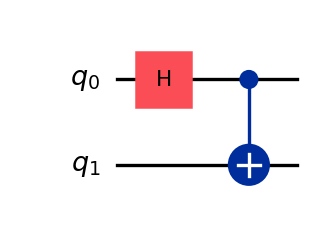

Statevector |Phi+>: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
Counts (1024 shots): {'11': 514, '00': 510}


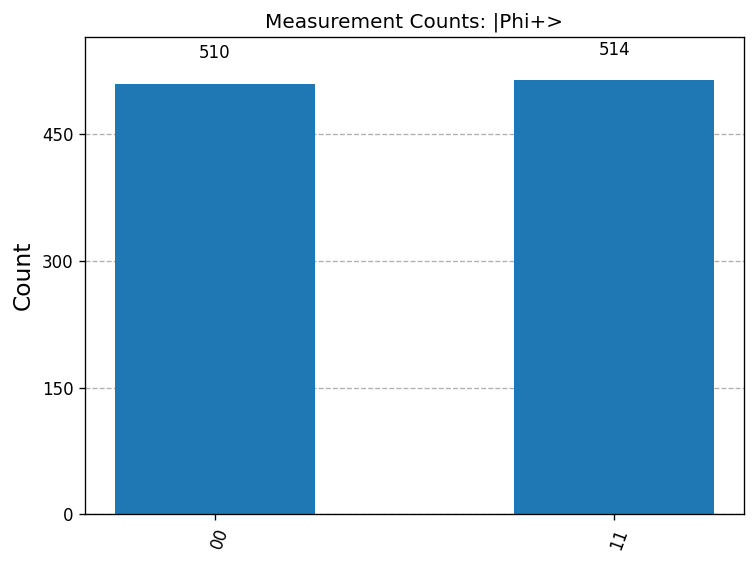


========================= Bell State: |Phi-> =========================


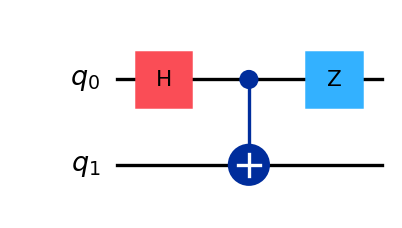

Statevector |Phi->: [ 0.7071+0.j  0.    +0.j  0.    +0.j -0.7071+0.j]
Counts (1024 shots): {'11': 514, '00': 510}


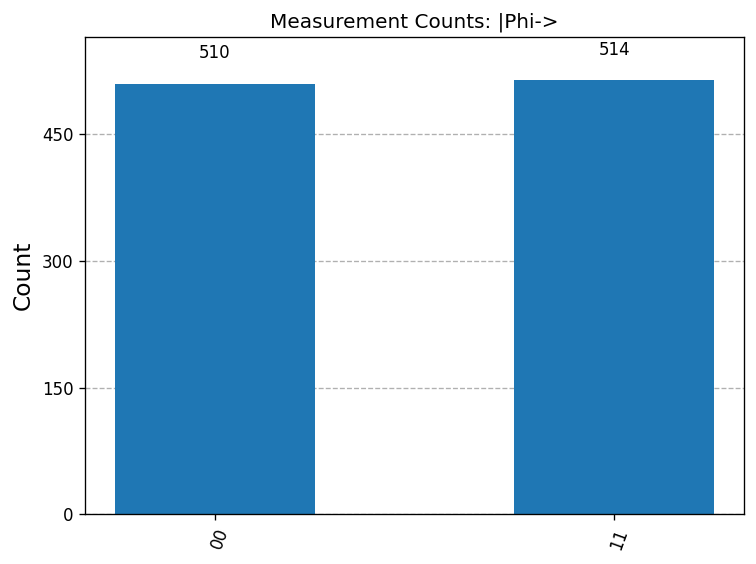


========================= Bell State: |Psi+> =========================


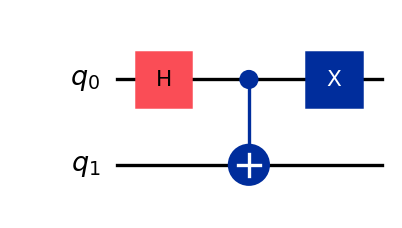

Statevector |Psi+>: [0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j]
Counts (1024 shots): {'01': 514, '10': 510}


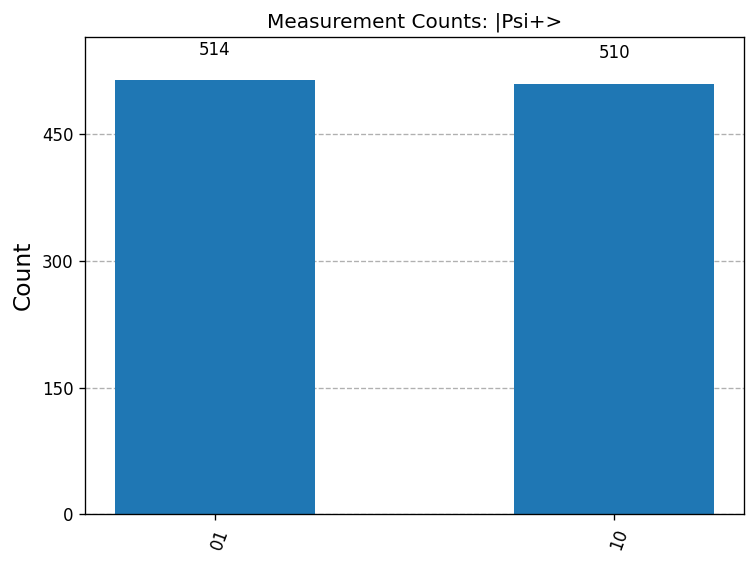


========================= Bell State: |Psi-> =========================


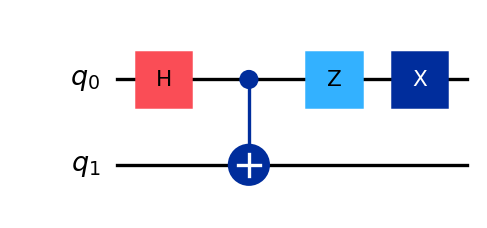

Statevector |Psi->: [ 0.    +0.j  0.7071+0.j -0.7071+0.j  0.    +0.j]
Counts (1024 shots): {'01': 514, '10': 510}


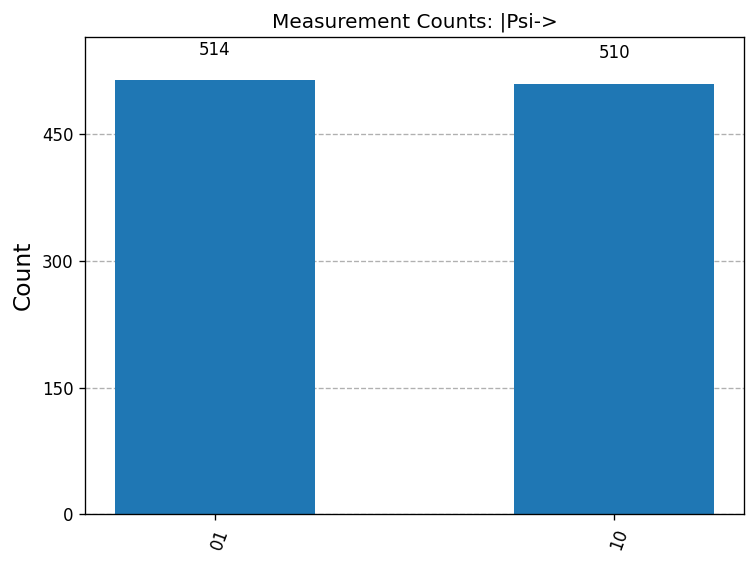

In [80]:
# Section 5: Construction, Statevectors & Simulation of 4 Bell States

bell_circuits = {}
bell_statevectors = {}
bell_counts = {}

# 1. |Phi+> = (|00> + |11>) / sqrt(2)
qc_phi_p = QuantumCircuit(2, name="Phi+")
qc_phi_p.h(0)
qc_phi_p.cx(0, 1)
bell_circuits['Phi+'] = qc_phi_p

# 2. |Phi-> = (|00> - |11>) / sqrt(2)
qc_phi_m = QuantumCircuit(2, name="Phi-")
qc_phi_m.h(0)
qc_phi_m.cx(0, 1)
qc_phi_m.z(0)
bell_circuits['Phi-'] = qc_phi_m

# 3. |Psi+> = (|01> + |10>) / sqrt(2)
qc_psi_p = QuantumCircuit(2, name="Psi+")
qc_psi_p.h(0)
qc_psi_p.cx(0, 1)
qc_psi_p.x(0)
bell_circuits['Psi+'] = qc_psi_p

# 4. |Psi-> = (|01> - |10>) / sqrt(2)
qc_psi_m = QuantumCircuit(2, name="Psi-")
qc_psi_m.h(0)
qc_psi_m.cx(0, 1)
qc_psi_m.z(0)
qc_psi_m.x(0)
bell_circuits['Psi-'] = qc_psi_m

# Execute each Bell state circuit
for name, circ in bell_circuits.items():
    print(f"\n{'='*25} Bell State: |{name}> {'='*25}")
    display(circ.draw("mpl"))

    # Statevector before measurement
    sv = Statevector(circ)
    bell_statevectors[name] = sv
    print(f"Statevector |{name}>: {np.round(sv.data, 4)}")

    # 1024 measurement shots
    circ_meas = circ.copy()
    circ_meas.measure_all()
    counts = simulator.run(circ_meas, shots=SHOTS, seed_simulator=123).result().get_counts()
    bell_counts[name] = counts
    print(f"Counts (1024 shots): {counts}")
    display(plot_histogram(counts, title=f"Measurement Counts: |{name}>"))


## 5.1 Bell States Summary Table

| Bell State | Statevector | Possible Outcomes | Approx. Probability |
| :---: | :---: | :---: | :---: |
| **$\Phi^+$** | $\frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|11\rangle = \begin{pmatrix} 1/\sqrt{2} \\ 0 \\ 0 \\ 1/\sqrt{2} \end{pmatrix}$ | $\{00, 11\}$ | $P(00) \approx 0.50$, $P(11) \approx 0.50$ |
| **$\Phi^-$** | $\frac{1}{\sqrt{2}}|00\rangle - \frac{1}{\sqrt{2}}|11\rangle = \begin{pmatrix} 1/\sqrt{2} \\ 0 \\ 0 \\ -1/\sqrt{2} \end{pmatrix}$ | $\{00, 11\}$ | $P(00) \approx 0.50$, $P(11) \approx 0.50$ |
| **$\Psi^+$** | $\frac{1}{\sqrt{2}}|01\rangle + \frac{1}{\sqrt{2}}|10\rangle = \begin{pmatrix} 0 \\ 1/\sqrt{2} \\ 1/\sqrt{2} \\ 0 \end{pmatrix}$ | $\{01, 10\}$ | $P(01) \approx 0.50$, $P(10) \approx 0.50$ |
| **$\Psi^-$** | $\frac{1}{\sqrt{2}}|01\rangle - \frac{1}{\sqrt{2}}|10\rangle = \begin{pmatrix} 0 \\ 1/\sqrt{2} \\ -1/\sqrt{2} \\ 0 \end{pmatrix}$ | $\{01, 10\}$ | $P(01) \approx 0.50$, $P(10) \approx 0.50$ |


## 5.2 Physical Origin of Probability Invariance Under Relative Phase

### Why $\Phi^+$ and $\Phi^-$ Produce Identical Measurement Probabilities
The statevectors $|\Phi^+\rangle$ and $|\Phi^-\rangle$ differ exclusively by an internal relative phase factor of $e^{i\pi} = -1$ on the $|11\rangle$ computational component:
$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}, \quad |\Phi^-\rangle = \frac{|00\rangle + e^{i\pi}|11\rangle}{\sqrt{2}} = \frac{|00\rangle - |11\rangle}{\sqrt{2}}$$
Under the Born rule, projective measurement in the computational basis evaluates the squared moduli of the amplitudes:
$$P(x) = |\langle x | \psi \rangle|^2$$
For $|\Phi^+\rangle$:
$$P(00) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2}, \quad P(11) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2}$$
For $|\Phi^-\rangle$:
$$P(00) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2}, \quad P(11) = \left|-\frac{1}{\sqrt{2}}\right|^2 = \left|\frac{e^{i\pi}}{\sqrt{2}}\right|^2 = \frac{|e^{i\pi}|^2}{2} = \frac{1}{2}$$
Because $|e^{i\theta}| = 1$ for any real $\theta$, squaring the complex modulus eliminates the relative phase. Computational-basis measurements correspond to measuring diagonal projection operators $\Pi_x = |x\rangle\langle x|$, which cannot detect non-diagonal phase coherences.

### Corresponding Relationship Between $\Psi^+$ and $\Psi^-$
An identical physical mechanism relates $|\Psi^+\rangle$ and $|\Psi^-\rangle$. Both states are supported strictly on the odd-parity subspace $\{|01\rangle, |10\rangle\}$ with amplitudes of magnitude $1/\sqrt{2}$. The phase factor $e^{i\pi} = -1$ multiplying the $|10\rangle$ component vanishes under modulus squaring:
$$P(01) = \left|\frac{1}{\sqrt{2}}\right|^2 = 0.50, \quad P(10) = \left|\pm\frac{1}{\sqrt{2}}\right|^2 = 0.50$$
To distinguish $|\Phi^+\rangle$ from $|\Phi^-\rangle$ (or $|\Psi^+\rangle$ from $|\Psi^-\rangle$), one must measure in a complementary, non-commuting observable basis, such as $X \otimes X$, where:
$$(X \otimes X)|\Phi^+\rangle = +1|\Phi^+\rangle, \quad (X \otimes X)|\Phi^-\rangle = -1|\Phi^-\rangle$$
$$(X \otimes X)|\Psi^+\rangle = +1|\Psi^+\rangle, \quad (X \otimes X)|\Psi^-\rangle = -1|\Psi^-\rangle$$


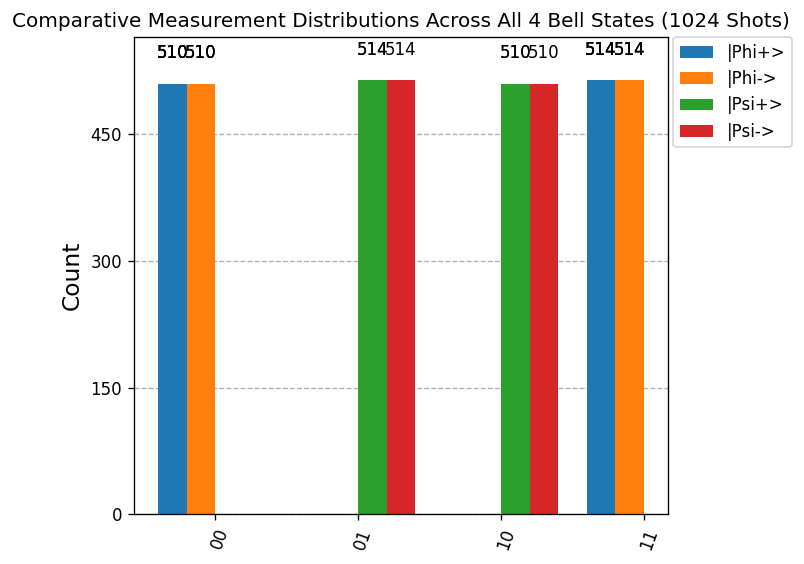


Orthonormality Matrix (Inner Products <B_i | B_j>):
          Phi+    Phi-    Psi+    Psi-
  Phi+:   1.00    0.00    0.00    0.00
  Phi-:   0.00    1.00    0.00    0.00
  Psi+:   0.00    0.00    1.00    0.00
  Psi-:   0.00    0.00    0.00    1.00


In [81]:
# Section 5.3: Comparative Visualization of All Four Bell States

fig_bell_all = plot_histogram(
    [bell_counts['Phi+'], bell_counts['Phi-'], bell_counts['Psi+'], bell_counts['Psi-']],
    legend=["|Phi+>", "|Phi->", "|Psi+>", "|Psi->"],
    title="Comparative Measurement Distributions Across All 4 Bell States (1024 Shots)"
)
display(fig_bell_all)

# Check mutual orthogonality of Bell states: <B_i | B_j> = delta_ij
print("\nOrthonormality Matrix (Inner Products <B_i | B_j>):")
states_list = ['Phi+', 'Phi-', 'Psi+', 'Psi-']
ortho_matrix = np.zeros((4, 4))
for i, s1 in enumerate(states_list):
    for j, s2 in enumerate(states_list):
        ortho_matrix[i, j] = np.abs(np.vdot(bell_statevectors[s1].data, bell_statevectors[s2].data))

print("        " + "  ".join([f"{s:>6}" for s in states_list]))
for i, s1 in enumerate(states_list):
    row = f"{s1:>6}: " + "  ".join([f"{ortho_matrix[i, j]:6.2f}" for j in range(4)])
    print(row)


# 6. Entanglement Detective — Final Challenge

## Objective
We are given three quantum circuits. For each circuit, we will:
1. Implement the circuit in Qiskit.
2. Obtain the theoretical statevector.
3. Run 1024 measurement shots and plot the histogram.
4. Determine whether the terminal state is **entangled** or **separable**.
5. Provide a rigorous explanation based on quantum state algebra and circuit dynamics.

*Important Constraint:* Entanglement must not be determined solely from whether measurement results appear correlated. The quantum state and circuit structure must be rigorously evaluated.


## 6.1 Circuit 1
```
q0: ── H ──●────
           │
q1: ───────X────
```

### Step-by-Step Derivation
1. Initial state: $|\psi_0\rangle = |00\rangle = |0\rangle_1 \otimes |0\rangle_0$
2. After $H(q_0)$:
   $$|\psi_1\rangle = (I \otimes H)|00\rangle = |0\rangle_1 \otimes \frac{|0\rangle_0 + |1\rangle_0}{\sqrt{2}} = \frac{|00\rangle + |01\rangle}{\sqrt{2}}$$
3. After $CX_{(0 \to 1)}$:
   $$|\psi_{\text{final}}\rangle = CX_{(0 \to 1)}|\psi_1\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} = |\Phi^+\rangle$$

### Classification & Reasoning: **ENTANGLED**
- **Non-Factorability:** The state cannot be written as $(a|0\rangle + b|1\rangle) \otimes (c|0\rangle + d|1\rangle)$ because $(ac)(bd) = 1/2 \neq (ad)(bc) = 0$.
- **Schmidt Rank:** $r = 2$ with coefficients $\lambda_1 = \lambda_2 = 1/\sqrt{2}$.
- **Subsystem Metrics:** The reduced density matrix $\rho_0 = \mathrm{Tr}_1(|\Phi^+\rangle\langle\Phi^+|) = \frac{1}{2}I_2$ is maximally mixed, yielding purity $\gamma = 0.50$ and entanglement entropy $S(\rho_0) = 1.00$ ebit.
- **Circuit Mechanism:** The entangling CNOT gate correlates the superposition state of the control qubit with the target qubit.


Detective Circuit 1 Diagram:


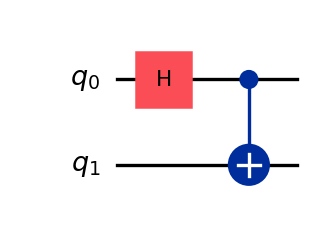

Statevector: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
Subsystem 0 Purity: 0.5000
Entanglement Entropy: 1.0000 ebits
Conclusion: MAXIMALLY ENTANGLED (Schmidt Rank = 2)
Counts (1024 shots): {'00': 503, '11': 521}


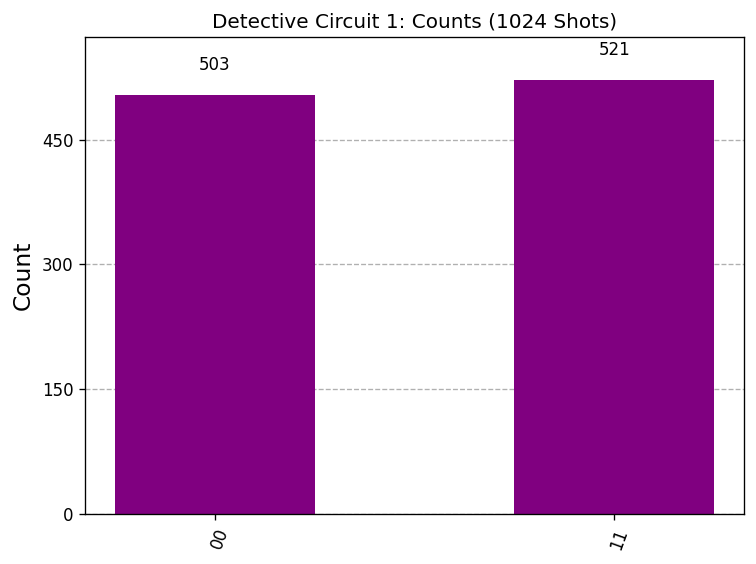

In [82]:
# Section 6.1: Detective Circuit 1 Implementation

qc_det1 = QuantumCircuit(2, name="Detective Circuit 1")
qc_det1.h(0)
qc_det1.cx(0, 1)

print("Detective Circuit 1 Diagram:")
display(qc_det1.draw("mpl"))

state_det1 = Statevector(qc_det1)
print(f"Statevector: {np.round(state_det1.data, 4)}")

# Entanglement metrics
rho_det1 = DensityMatrix(state_det1)
rho_0_det1 = partial_trace(rho_det1, [1])
s_det1 = entropy(rho_0_det1, base=2)
purity_det1 = np.trace(np.dot(rho_0_det1.data, rho_0_det1.data)).real

print(f"Subsystem 0 Purity: {purity_det1:.4f}")
print(f"Entanglement Entropy: {s_det1:.4f} ebits")
print("Conclusion: MAXIMALLY ENTANGLED (Schmidt Rank = 2)")

qc_det1_meas = qc_det1.copy()
qc_det1_meas.measure_all()
counts_det1 = simulator.run(qc_det1_meas, shots=SHOTS, seed_simulator=7).result().get_counts()
print(f"Counts (1024 shots): {counts_det1}")
display(plot_histogram(counts_det1, title="Detective Circuit 1: Counts (1024 Shots)", color="purple"))


## 6.2 Circuit 2
```
q0: ── H ──
q1: ── H ──
```

### Step-by-Step Derivation
1. Initial state: $|\psi_0\rangle = |00\rangle = |0\rangle_1 \otimes |0\rangle_0$
2. After independent Hadamards:
   $$|\psi_{\text{final}}\rangle = (H \otimes H)|00\rangle = (H|0\rangle_1) \otimes (H|0\rangle_0) = |+\rangle_1 \otimes |+\rangle_0 = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)$$

### Classification & Reasoning: **SEPARABLE**
- **Factorability:** The composite state factors directly into $|\psi_1\rangle \otimes |\psi_0\rangle = |+\rangle \otimes |+\rangle$.
- **Circuit Topology:** The circuit contains no two-qubit entangling gates. By definition, local unitaries cannot create bipartite entanglement from a separable state.
- **Schmidt Rank:** $r = 1$.
- **Subsystem Metrics:** The reduced density matrix $\rho_0 = |+\rangle\langle+|$ is a pure state, with purity $\gamma = 1.00$ and entanglement entropy $S(\rho_0) = 0.00$ ebits.


Detective Circuit 2 Diagram:


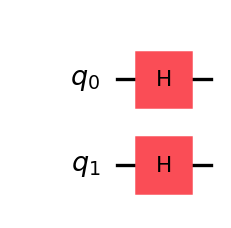

Statevector: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Subsystem 0 Purity: 1.0000
Entanglement Entropy: 0.0000 ebits
Conclusion: SEPARABLE (Product State, Schmidt Rank = 1)
Counts (1024 shots): {'11': 249, '00': 267, '10': 236, '01': 272}


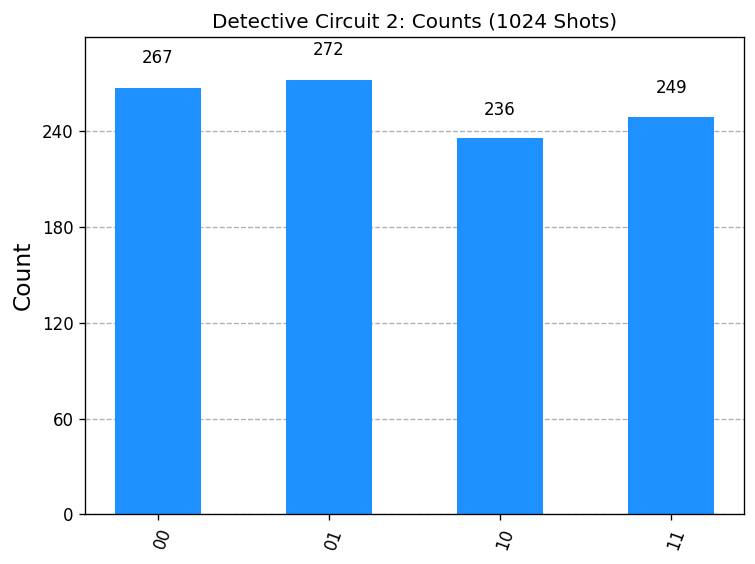

In [83]:
# Section 6.2: Detective Circuit 2 Implementation

qc_det2 = QuantumCircuit(2, name="Detective Circuit 2")
qc_det2.h(0)
qc_det2.h(1)

print("Detective Circuit 2 Diagram:")
display(qc_det2.draw("mpl"))

state_det2 = Statevector(qc_det2)
print(f"Statevector: {np.round(state_det2.data, 4)}")

# Entanglement metrics
rho_det2 = DensityMatrix(state_det2)
rho_0_det2 = partial_trace(rho_det2, [1])
s_det2 = entropy(rho_0_det2, base=2)
purity_det2 = np.trace(np.dot(rho_0_det2.data, rho_0_det2.data)).real

print(f"Subsystem 0 Purity: {purity_det2:.4f}")
print(f"Entanglement Entropy: {s_det2:.4f} ebits")
print("Conclusion: SEPARABLE (Product State, Schmidt Rank = 1)")

qc_det2_meas = qc_det2.copy()
qc_det2_meas.measure_all()
counts_det2 = simulator.run(qc_det2_meas, shots=SHOTS, seed_simulator=7).result().get_counts()
print(f"Counts (1024 shots): {counts_det2}")
display(plot_histogram(counts_det2, title="Detective Circuit 2: Counts (1024 Shots)", color="dodgerblue"))


## 6.3 Circuit 3
```
q0: ── X ── H ──●────
                │
q1: ─────── H ──X────
```

### Step-by-Step Derivation
1. **Initial state ($t=0$):**
   $$|\psi_0\rangle = |00\rangle = |0\rangle_1 \otimes |0\rangle_0$$

2. **State prior to the CNOT gate ($t=1$):**
   - On control qubit $q_0$:
     $$|0\rangle_0 \xrightarrow{X} |1\rangle_0 \xrightarrow{H} |-\rangle_0 = \frac{|0\rangle_0 - |1\rangle_0}{\sqrt{2}}$$
   - On target qubit $q_1$:
     $$|0\rangle_1 \xrightarrow{H} |+\rangle_1 = \frac{|0\rangle_1 + |1\rangle_1}{\sqrt{2}}$$
   - Pre-gate bipartite state:
     $$|\psi_{\text{pre}}\rangle = |+\rangle_1 \otimes |-\rangle_0$$

3. **Action of the CNOT Gate ($q_0$ control, $q_1$ target):**
   The controlled unitary operator is:
   $$CX_{(0 \to 1)} = |0\rangle\langle 0|_0 \otimes I_1 + |1\rangle\langle 1|_0 \otimes X_1$$
   Applying this to $|\psi_{\text{pre}}\rangle = |+\rangle_1 \otimes |-\rangle_0$:
   $$CX_{(0 \to 1)} (|+\rangle_1 \otimes |-\rangle_0) = CX_{(0 \to 1)}\left( |+\rangle_1 \otimes \frac{|0\rangle_0 - |1\rangle_0}{\sqrt{2}} \right)$$
   Evaluating term-by-term:
   - For $|0\rangle_0$: Target receives $I_1 \implies |+\rangle_1 \otimes |0\rangle_0$
   - For $|1\rangle_0$: Target receives $X_1 \implies (X_1 |+\rangle_1) \otimes |1\rangle_0$
   Specifically, $|+\rangle_1$ is an **eigenstate of the Pauli-$X$ operator** with eigenvalue $+1$:
   $$X_1 |+\rangle_1 = (+1)|+\rangle_1$$
   Therefore:
   $$(X_1 |+\rangle_1) \otimes |1\rangle_0 = |+\rangle_1 \otimes |1\rangle_0$$
   Combining both terms:
   $$CX_{(0 \to 1)} (|+\rangle_1 \otimes |-\rangle_0) = |+\rangle_1 \otimes \left(\frac{|0\rangle_0 - |1\rangle_0}{\sqrt{2}}\right) = |+\rangle_1 \otimes |-\rangle_0$$

### Classification & Reasoning: **SEPARABLE**
- **Operator Invariance:** Because the target qubit is in the $+1$ eigenstate of the conditional operator $X$, the CNOT gate acts as the identity transformation on this specific state:
  $$CX_{(0 \to 1)} (|+\rangle_1 \otimes |-\rangle_0) = |+\rangle_1 \otimes |-\rangle_0$$
- **Factorability:** The terminal state is an unentangled product state:
  $$|\psi_{\text{final}}\rangle = |+\rangle_1 \otimes |-\rangle_0 = \frac{1}{2}(|00\rangle - |01\rangle + |10\rangle - |11\rangle)$$
- **Schmidt Rank:** $r = 1$.
- **Subsystem Metrics:** The reduced density matrix $\rho_0 = |-\rangle\langle-|$ has purity $\gamma = 1.00$ and entanglement entropy $S(\rho_0) = 0.00$ ebits.
- **Resolution of the Detective Problem:** Although Circuit 3 includes an entangling CNOT gate and yields all four computational outcomes with equal probability ($P \approx 0.25$), **no entanglement is generated**. Entanglement is a property of the global quantum state in Hilbert space, not simply whether a multi-qubit gate appears in the circuit diagram.


Detective Circuit 3 Diagram:


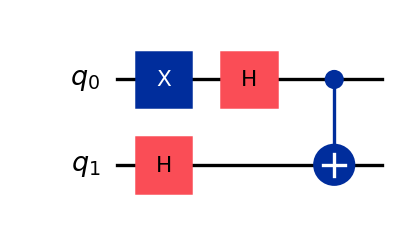

Statevector: [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]
Subsystem 0 Purity: 1.0000
Entanglement Entropy: 0.0000 ebits
Conclusion: SEPARABLE (Product State, Schmidt Rank = 1)
Counts (1024 shots): {'11': 249, '00': 267, '10': 236, '01': 272}


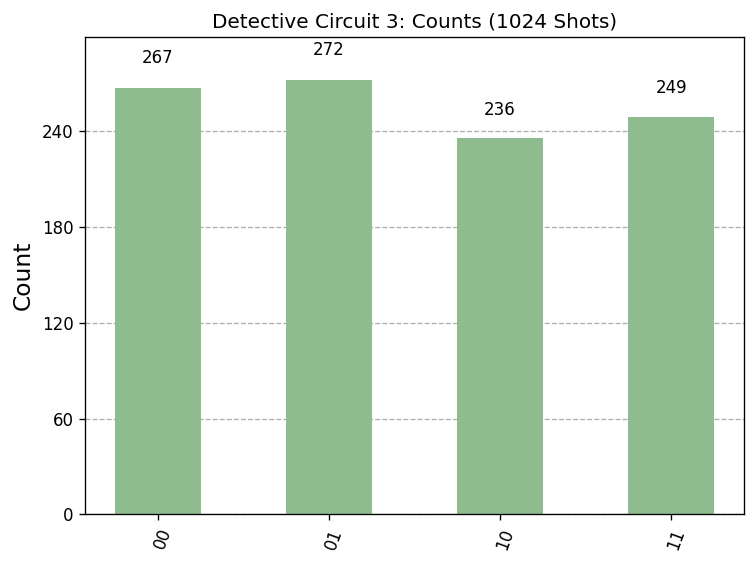

In [84]:
# Section 6.3: Detective Circuit 3 Implementation

qc_det3 = QuantumCircuit(2, name="Detective Circuit 3")
qc_det3.x(0)
qc_det3.h(0)
qc_det3.h(1)
qc_det3.cx(0, 1)

print("Detective Circuit 3 Diagram:")
display(qc_det3.draw("mpl"))

state_det3 = Statevector(qc_det3)
print(f"Statevector: {np.round(state_det3.data, 4)}")

# Entanglement metrics
rho_det3 = DensityMatrix(state_det3)
rho_0_det3 = partial_trace(rho_det3, [1])
s_det3 = entropy(rho_0_det3, base=2)
purity_det3 = np.trace(np.dot(rho_0_det3.data, rho_0_det3.data)).real

print(f"Subsystem 0 Purity: {purity_det3:.4f}")
print(f"Entanglement Entropy: {s_det3:.4f} ebits")
print("Conclusion: SEPARABLE (Product State, Schmidt Rank = 1)")

qc_det3_meas = qc_det3.copy()
qc_det3_meas.measure_all()
counts_det3 = simulator.run(qc_det3_meas, shots=SHOTS, seed_simulator=7).result().get_counts()
print(f"Counts (1024 shots): {counts_det3}")
display(plot_histogram(counts_det3, title="Detective Circuit 3: Counts (1024 Shots)", color="darkseagreen"))


## 6.4 Entanglement Detective Summary Table

| Circuit | Gate Operations | Terminal Statevector | Classification | Schmidt Rank ($r$) | Entropy $S(\rho_0)$ | Physical & Algebraic Explanation |
| :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **1** | $H_0 \to CX_{(0 \to 1)}$ | $\frac{\|00\rangle + \|11\rangle}{\sqrt{2}}$ | **Entangled** | $2$ | $1.00$ ebit | Control qubit superposition is mapped to maximally correlated bipartite state via CNOT. |
| **2** | $H_0, H_1$ | $\|+\rangle_1 \otimes \|+\rangle_0$ | **Separable** | $1$ | $0.00$ ebits | Pure product state generated strictly by local single-qubit rotations. |
| **3** | $X_0 \to H_0, H_1 \to CX_{(0 \to 1)}$ | $\|+\rangle_1 \otimes \|-\rangle_0$ | **Separable** | $1$ | $0.00$ ebits | Target qubit is prepared in $\|+\rangle_1$, the $+1$ eigenstate of $X$; the CNOT gate acts as the identity. |


# 7. Conceptual Questions

## Q1. What is the difference between a single-qubit superposition and a two-qubit entangled state?
A single-qubit superposition is a linear combination of orthonormal basis states within an individual two-dimensional Hilbert space, $|\psi\rangle = \alpha |0\rangle + \beta |1\rangle \in \mathcal{H}_2$, where the state of the qubit is fully specified and locally isolated. In contrast, a two-qubit entangled state is a non-separable state in the composite Hilbert space $\mathcal{H}_2 \otimes \mathcal{H}_2$ that cannot be factored into a tensor product of independent states, $|\Psi\rangle \neq |\psi_1\rangle \otimes |\psi_0\rangle$. In an entangled state, individual subsystems do not possess definite individual statevectors, and local measurements on the sub-registers yield non-classical correlations that violate Bell inequalities.

## Q2. What role does the CNOT gate play in creating a Bell state?
The CNOT gate acts as a conditional two-qubit entangling operator that applies a Pauli-$X$ bit-flip to the target qubit conditioned on the control qubit being in the state $|1\rangle$. When the control qubit is first prepared in an equal superposition state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ and the target qubit is in $|0\rangle$, the CNOT gate acts linearly to map the product state $\frac{1}{\sqrt{2}}(|00\rangle + |01\rangle)$ into the non-separable Bell state $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$. Thus, the CNOT gate converts local quantum phase coherence into non-local bipartite quantum entanglement across the composite system.

## Q3. Why can two different quantum states produce the same computational-basis measurement probabilities?
According to the Born rule, projective measurement in the computational basis evaluates the squared magnitude of each complex probability amplitude, $P(x) = |\langle x | \psi \rangle|^2$. Expressing any amplitude in polar form as $\alpha_x = r_x e^{i\theta_x}$, the outcome probability is given by $P(x) = r_x^2$, which is invariant under changes to the phase $\theta_x$. Consequently, two orthogonal quantum states that differ solely in their relative phases—such as $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ and $|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$—yield identical probability distributions in the computational basis while remaining fully distinguishable in complementary bases such as $X \otimes X$.

## Q4. What is the difference between a Statevector and measurement counts in Qiskit?
In Qiskit, a `Statevector` represents the exact, deterministic mathematical state vector $|\psi\rangle$ in complex Hilbert space, containing all continuous complex amplitudes and phase information without measurement collapse. In contrast, measurement counts represent empirical, integer statistical frequencies obtained by sampling a finite number of simulated or hardware shots in a designated measurement basis. Measurement counts are stochastic, undergo projective wavefunction collapse, and exhibit statistical sampling noise (shot noise) that approximates the theoretical Born probabilities only as the number of shots approaches infinity.

## Q5. How many computational-basis states are possible for:
- **1 qubit:** $2^1 = 2$ states ($\{|0\rangle, |1\rangle\}$)
- **2 qubits:** $2^2 = 4$ states ($\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$)
- **3 qubits:** $2^3 = 8$ states ($\{|000\rangle, |001\rangle, \dots, |111\rangle\}$)
- **5 qubits:** $2^5 = 32$ states ($\{|00000\rangle, \dots, |11111\rangle\}$)
- **$n$ qubits:** $2^n$ states

### Explanation of the Relationship
The state space of an $n$-qubit register is the tensor product of $n$ individual two-dimensional single-qubit complex Hilbert spaces:
$$\mathcal{H}^{\otimes n} = \bigotimes_{k=1}^n \mathbb{C}^2 \cong \mathbb{C}^{2^n}$$
Because each individual qubit has a basis of dimension 2 ($\{|0\rangle, |1\rangle\}$), the dimension of the composite product space equals the product of the individual dimensions:
$$\dim(\mathcal{H}^{\otimes n}) = \prod_{k=1}^n 2 = 2^n$$
This fundamental exponential scaling enables a quantum register of $n$ qubits to simultaneously process linear combinations of $2^n$ computational basis states, which forms the core computational advantage of quantum algorithms over classical architectures.
